In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

import scipy.cluster.hierarchy as sch


In [2]:

from google.colab import files

uploaded = files.upload()


Saving Mall_Customers.csv to Mall_Customers.csv


In [3]:
df = pd.read_csv("Mall_Customers.csv")

In [4]:
print(df.head())

print("\nDataset Shape:")
print(df.shape)


   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset Shape:
(200, 5)


In [5]:
X = df[
    [
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
]



In [6]:

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


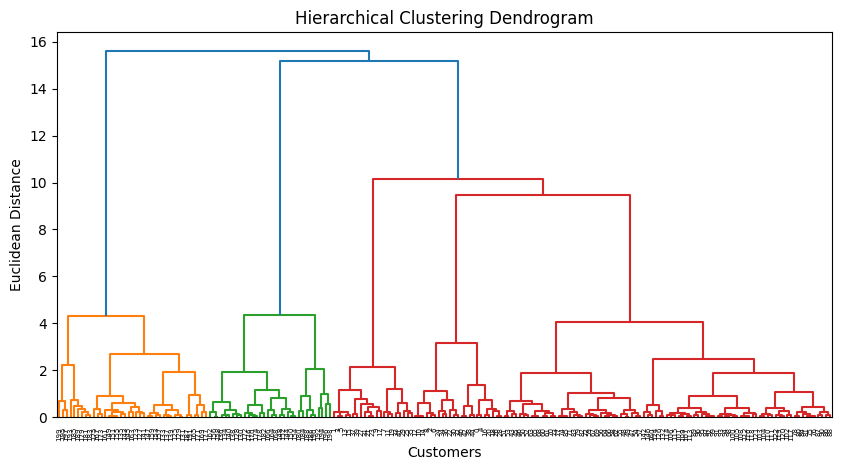

In [7]:
plt.figure(figsize=(10,5))


sch.dendrogram(
    sch.linkage(
        X_scaled,
        method="ward"
    )
)


plt.title("Hierarchical Clustering Dendrogram")

plt.xlabel("Customers")

plt.ylabel("Euclidean Distance")


plt.show()


In [8]:

hierarchical = AgglomerativeClustering(
    n_clusters=5,
    linkage="ward"
)


clusters = hierarchical.fit_predict(X_scaled)


In [9]:
df["Cluster"] = clusters



print("\nClustered Data:")
print(df.head())



Clustered Data:
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        3  
2        4  
3        3  
4        4  


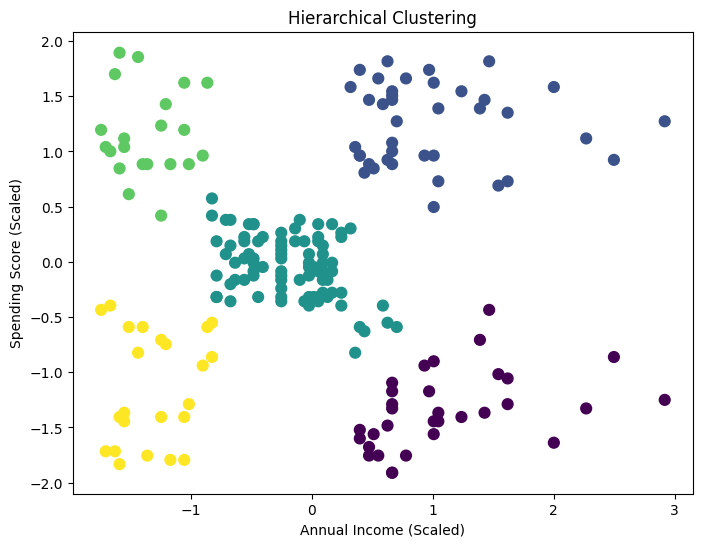

In [10]:

plt.figure(figsize=(8,6))


plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=clusters,
    s=60
)


plt.xlabel("Annual Income (Scaled)")

plt.ylabel("Spending Score (Scaled)")


plt.title("Hierarchical Clustering")


plt.show()


In [11]:
silhouette = silhouette_score(
    X_scaled,
    clusters
)


print(
    "\nHierarchical Clustering Silhouette Score:",
    silhouette
)




Hierarchical Clustering Silhouette Score: 0.5538089226688662


In [12]:

print("\nCluster Counts:")

print(
    df["Cluster"].value_counts()
)


Cluster Counts:
Cluster
2    85
1    39
0    32
4    23
3    21
Name: count, dtype: int64
